In [1]:
import pandas as pd

df = pd.read_csv("../data/cs-training.csv", index_col=0)
print(df.shape)
df.head()

(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [4]:
df["SeriousDlqin2yrs"].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [5]:
df["NumberOfTimes90DaysLate"].value_counts().sort_index().tail(6)

NumberOfTimes90DaysLate
13      4
14      2
15      2
17      1
96      5
98    264
Name: count, dtype: int64

In [6]:
mask = df["NumberOfTimes90DaysLate"] >= 90
print("строк в группе:", mask.sum())
print("доля дефолтов в группе:", df.loc[mask, "SeriousDlqin2yrs"].mean().round(4))
print("доля дефолтов везде:  ", df["SeriousDlqin2yrs"].mean().round(4))

строк в группе: 269
доля дефолтов в группе: 0.5465
доля дефолтов везде:   0.0668


In [7]:
no_income = df["MonthlyIncome"].isna()
print("доля дефолтов, доход пропущен:", df.loc[no_income, "SeriousDlqin2yrs"].mean().round(4))
print("доля дефолтов, доход известен:", df.loc[~no_income, "SeriousDlqin2yrs"].mean().round(4))
print()
print("медиана DebtRatio, доход пропущен:", df.loc[no_income, "DebtRatio"].median())
print("медиана DebtRatio, доход известен:", df.loc[~no_income, "DebtRatio"].median())

доля дефолтов, доход пропущен: 0.0561
доля дефолтов, доход известен: 0.0695

медиана DebtRatio, доход пропущен: 1159.0
медиана DebtRatio, доход известен: 0.296022604


In [8]:
mask = df["RevolvingUtilizationOfUnsecuredLines"] >= 1
print("строк в группе:", mask.sum())
print("доля дефолтов в группе:", df.loc[mask, "SeriousDlqin2yrs"].mean().round(4))
print("доля дефолтов везде:  ", df["SeriousDlqin2yrs"].mean().round(4))

строк в группе: 3338
доля дефолтов в группе: 0.3718
доля дефолтов везде:   0.0668


In [9]:
no_income = df["MonthlyIncome"].isna()
print(df.loc[no_income, "age"].median(), df.loc[~no_income, "age"].median())

57.0 51.0


In [10]:
no_income = df["NumberOfDependents"].isna()
print("доля дефолтов, значение пропущено:", df.loc[no_income, "SeriousDlqin2yrs"].mean().round(4))
print("доля дефолтов, значение известено:", df.loc[~no_income, "SeriousDlqin2yrs"].mean().round(4))

доля дефолтов, значение пропущено: 0.0456
доля дефолтов, значение известено: 0.0674


## Найденные проблемы и решения

Проверка каждой аномалии: сравниваю долю дефолтов в группе с базовой (6,68%).

| # | Находка | Масштаб | Дефолт в группе | Решение |
|---|---------|---------|-----------------|---------|
| 1 | Коды 96 и 98 в счётчиках просрочек | 269 строк (0,18%) | 54,7% | → `NaN` + бинарный флаг `late_code` |
| 2 | Пропуски в `MonthlyIncome` | 29 731 (19,8%) | 5,6% против 6,9% | флаг `income_missing` + медиана внутри Pipeline |
| 3 | `DebtRatio` у строк без дохода — сумма, а не отношение | те же 19,8% | — | покрывается флагом `income_missing` |
| 4 | `RevolvingUtilization` > 1 | 3 338 (2,2%) | 37,2% | строки оставляем; клиппинг по 99-му перцентилю только для линейных моделей |
| 5 | `age` = 0 | 1 строка | — | удалить |
| 6 | Пропуски в `NumberOfDependents` | 3 924 (2,6%) | 4,6% против 6,7% | заполнить нулём |

**Общий принцип:** строки с аномалиями не удаляю, так как в них сосредоточена
непропорционально большая доля дефолтов. Все преобразования выполняются
внутри pipeline после разделения выборок, чтобы избежать утечки.

## Разделение выборок

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["SeriousDlqin2yrs"])
y = df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(X_train.shape, X_test.shape)
print("доля дефолтов train:", y_train.mean().round(4))
print("доля дефолтов test: ", y_test.mean().round(4))

(120000, 10) (30000, 10)
доля дефолтов train: 0.0668
доля дефолтов test:  0.0668


## Журнал экспериментов

| # | Что сделано | CV ROC-AUC | Разброс |
|---|-------------|------------|---------|
| 0 | DummyClassifier | 0.500 | — |
| 1 | Логрег на сырых признаках | 0,6939 | ±0,0096 |
| 2 | Логрег + флаги и маскирование кодов | 0,8133 | ±0,0034 |
| 3 | Бустниг на сырых признаках | 0,8630 | ±0,0028 |
| 4 | Бустинг + обработка | 0,8636 | ±0,0024 |

## Baseline

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# нулевая точка: модель, которая ничего не умеет
dummy = DummyClassifier(strategy="prior")
dummy_scores = cross_val_score(dummy, X_train, y_train, cv=cv, scoring="roc_auc")

# baseline: логистическая регрессия
logreg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(max_iter=1000)),
])
logreg_scores = cross_val_score(logreg, X_train, y_train, cv=cv,
                                scoring="roc_auc", n_jobs=-1)

print("dummy  ROC-AUC:", dummy_scores.mean().round(4))
print("logreg ROC-AUC:", logreg_scores.mean().round(4),
      "±", logreg_scores.std().round(4))

dummy  ROC-AUC: 0.5
logreg ROC-AUC: 0.6936 ± 0.0096


In [13]:
import numpy as np
from sklearn.preprocessing import FunctionTransformer

LATE_COLS = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

def add_features(X):
    X = X.copy()                      

    # 1. флаг служебных кодов 96/98 — до того, как мы их сотрём
    X["late_code"] = (X[LATE_COLS] >= 90).any(axis=1).astype(int)

    # 2. сами коды превращаем в пропуски
    X[LATE_COLS] = X[LATE_COLS].mask(X[LATE_COLS] >= 90)

    # 3. флаги пропусков
    X["income_missing"]     = X["MonthlyIncome"].isna().astype(int)
    X["dependents_missing"] = X["NumberOfDependents"].isna().astype(int)

    # 4. суммарное число просрочек всех типов
    X["late_total"] = X[LATE_COLS].sum(axis=1)

    return X

featurizer = FunctionTransformer(add_features)

logreg_v2 = Pipeline([
    ("features", featurizer),
    ("imputer",  SimpleImputer(strategy="median")),
    ("scaler",   StandardScaler()),
    ("model",    LogisticRegression(max_iter=1000)),
])

scores_v2 = cross_val_score(logreg_v2, X_train, y_train, cv=cv,
                            scoring="roc_auc", n_jobs=-1)
print("logreg v2:", scores_v2.mean().round(4), "±", scores_v2.std().round(4))

logreg v2: 0.8133 ± 0.0034


In [14]:
def make_features(mask_codes=True, add_flags=True, add_total=True):
    def f(X):
        X = X.copy()
        if add_flags:
            X["late_code"] = (X[LATE_COLS] >= 90).any(axis=1).astype(int)
        if mask_codes:
            X[LATE_COLS] = X[LATE_COLS].mask(X[LATE_COLS] >= 90)
        if add_flags:
            X["income_missing"]     = X["MonthlyIncome"].isna().astype(int)
            X["dependents_missing"] = X["NumberOfDependents"].isna().astype(int)
        if add_total:
            X["late_total"] = X[LATE_COLS].sum(axis=1)
        return X
    return f

configs = {
    "ничего (baseline)":        dict(mask_codes=False, add_flags=False, add_total=False),
    "только флаги":             dict(mask_codes=False, add_flags=True,  add_total=False),
    "только маскирование кодов":dict(mask_codes=True,  add_flags=False, add_total=False),
    "всё вместе":               dict(mask_codes=True,  add_flags=True,  add_total=True),
}

for name, kw in configs.items():
    pipe = Pipeline([
        ("features", FunctionTransformer(make_features(**kw))),
        ("imputer",  SimpleImputer(strategy="median")),
        ("scaler",   StandardScaler()),
        ("model",    LogisticRegression(max_iter=1000)),
    ])
    s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    print(f"{name:28s} {s.mean():.4f} ± {s.std():.4f}")

ничего (baseline)            0.6936 ± 0.0096
только флаги                 0.8125 ± 0.0035
только маскирование кодов    0.8078 ± 0.0031
всё вместе                   0.8133 ± 0.0034


In [15]:
from sklearn.ensemble import HistGradientBoostingClassifier

# вариант А: бустинг на сырых признаках, без обработки
hgb_raw = HistGradientBoostingClassifier(random_state=42)
s_raw = cross_val_score(hgb_raw, X_train, y_train, cv=cv,
                        scoring="roc_auc", n_jobs=-1)

# вариант Б: бустинг с обработкой
hgb_v2 = Pipeline([
    ("features", FunctionTransformer(make_features())),
    ("model",    HistGradientBoostingClassifier(random_state=42)),
])
s_v2 = cross_val_score(hgb_v2, X_train, y_train, cv=cv,
                       scoring="roc_auc", n_jobs=-1)

print("бустинг, сырые признаки:", s_raw.mean().round(4), "±", s_raw.std().round(4))
print("бустинг, с обработкой:  ", s_v2.mean().round(4), "±", s_v2.std().round(4))

бустинг, сырые признаки: 0.863 ± 0.0028
бустинг, с обработкой:   0.8636 ± 0.0024


In [16]:
from sklearn.model_selection import cross_val_predict
import numpy as np

model = Pipeline([
    ("features", FunctionTransformer(make_features())),
    ("model",    HistGradientBoostingClassifier(random_state=42)),
])

proba_oof = cross_val_predict(model, X_train, y_train, cv=cv,
                              method="predict_proba", n_jobs=-1)[:, 1]

print(proba_oof.shape)
print(proba_oof[:5].round(3))

(120000,)
[0.006 0.008 0.023 0.05  0.022]


In [17]:
y_arr = y_train.values
GAIN, LOSS = 1.0, -5.0

thresholds = np.linspace(0.01, 0.60, 120)
profits = np.array([
    ((proba_oof < t) & (y_arr == 0)).sum() * GAIN +
    ((proba_oof < t) & (y_arr == 1)).sum() * LOSS
    for t in thresholds
])

best_i    = profits.argmax()
t_best    = thresholds[best_i]
profit_all = (y_arr == 0).sum() * GAIN + (y_arr == 1).sum() * LOSS

print("оптимальный порог:      ", round(t_best, 3))
print("прибыль при оптимуме:   ", round(profits[best_i]))
print("прибыль, одобряя всех:  ", round(profit_all))
print("доля одобренных:        ", round((proba_oof < t_best).mean(), 3))
print("прирост прибыли:        ", f"{profits[best_i]/profit_all - 1:.1%}")

оптимальный порог:       0.164
прибыль при оптимуме:    86197
прибыль, одобряя всех:   71874
доля одобренных:         0.894
прирост прибыли:         19.9%


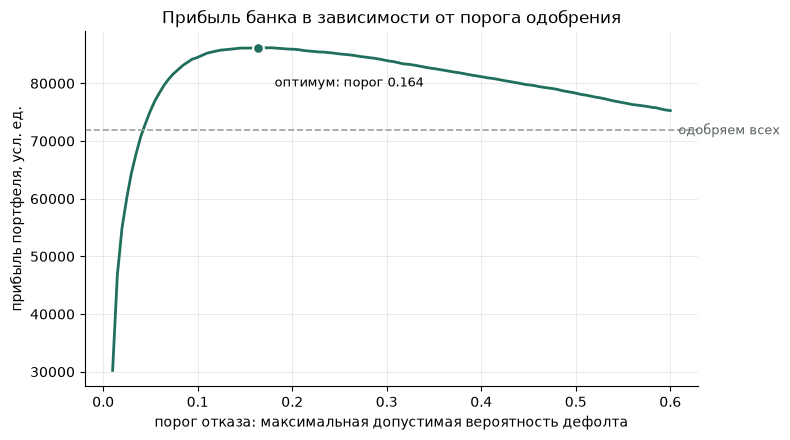

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, profits, lw=2, color="#1F6F5C")
ax.axhline(profit_all, ls="--", lw=1.2, color="#9AA39D")
ax.scatter([t_best], [profits[best_i]], s=60, zorder=5,
           color="#1F6F5C", edgecolor="white", linewidth=1.5)
ax.annotate(f"оптимум: порог {t_best:.3f}", xy=(t_best, profits[best_i]),
            xytext=(12, -28), textcoords="offset points", fontsize=9)
ax.text(thresholds[-1], profit_all, "  одобряем всех",
        va="center", fontsize=9, color="#5B635F")
ax.set_xlabel("порог отказа: максимальная допустимая вероятность дефолта")
ax.set_ylabel("прибыль портфеля, усл. ед.")
ax.set_title("Прибыль банка в зависимости от порога одобрения")
ax.grid(alpha=0.25, lw=0.7)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [19]:
print(f"{'LOSS':>6} {'порог':>8} {'теория':>8} {'одобрено':>10} {'прирост':>9}")
for loss in [-2, -3, -5, -8, -12]:
    pr = np.array([
        ((proba_oof < t) & (y_arr == 0)).sum() * GAIN +
        ((proba_oof < t) & (y_arr == 1)).sum() * loss
        for t in thresholds
    ])
    i = pr.argmax()
    base = (y_arr == 0).sum() * GAIN + (y_arr == 1).sum() * loss
    print(f"{loss:>6} {thresholds[i]:>8.3f} {1/(1-loss):>8.3f} "
          f"{(proba_oof < thresholds[i]).mean():>9.1%} {pr[i]/base - 1:>8.1%}")

  LOSS    порог   теория   одобрено   прирост
    -2    0.327    0.333     94.9%     2.7%
    -3    0.243    0.250     92.6%     6.8%
    -5    0.164    0.167     89.4%    19.9%
    -8    0.109    0.111     84.7%    61.0%
   -12    0.074    0.077     78.0%   331.4%


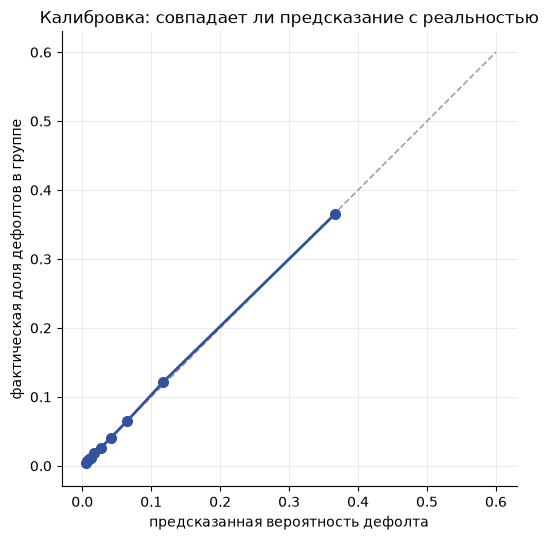

In [20]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_arr, proba_oof, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 0.6], [0, 0.6], ls="--", lw=1.2, color="#9AA39D")
ax.plot(prob_pred, prob_true, marker="o", ms=7, lw=2, color="#34519B")
ax.set_xlabel("предсказанная вероятность дефолта")
ax.set_ylabel("фактическая доля дефолтов в группе")
ax.set_title("Калибровка: совпадает ли предсказание с реальностью")
ax.grid(alpha=0.25, lw=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.set_aspect("equal")
plt.tight_layout()

In [21]:
from sklearn.inspection import permutation_importance

# отрезаем валидацию внутри train — отложенную выборку по-прежнему не трогаем
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42)

model.fit(X_tr, y_tr)

r = permutation_importance(model, X_val, y_val, scoring="roc_auc",
                           n_repeats=5, random_state=42, n_jobs=-1)

imp = (pd.Series(r.importances_mean, index=X_val.columns)
       .sort_values(ascending=True))
err = pd.Series(r.importances_std, index=X_val.columns).loc[imp.index]

for name, val in imp[::-1].items():
    print(f"{name:42s} {val:+.4f}")

RevolvingUtilizationOfUnsecuredLines       +0.0783
NumberOfTimes90DaysLate                    +0.0351
NumberOfTime30-59DaysPastDueNotWorse       +0.0339
NumberOfTime60-89DaysPastDueNotWorse       +0.0161
age                                        +0.0110
DebtRatio                                  +0.0059
MonthlyIncome                              +0.0058
NumberOfOpenCreditLinesAndLoans            +0.0047
NumberRealEstateLoansOrLines               +0.0030
NumberOfDependents                         +0.0002


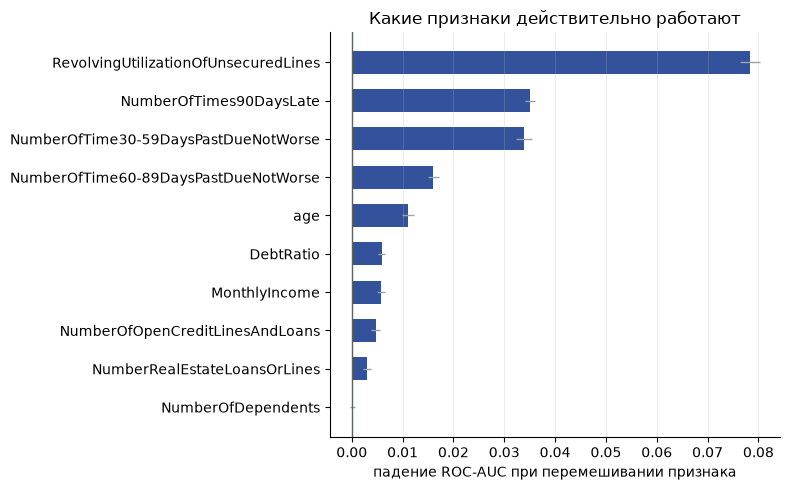

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp.index, imp.values, xerr=err.values, height=0.6,
        color="#34519B", error_kw=dict(lw=1, ecolor="#9AA39D"))
ax.axvline(0, lw=1, color="#5B635F")
ax.set_xlabel("падение ROC-AUC при перемешивании признака")
ax.set_title("Какие признаки действительно работают")
ax.grid(axis="x", alpha=0.25, lw=0.7)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

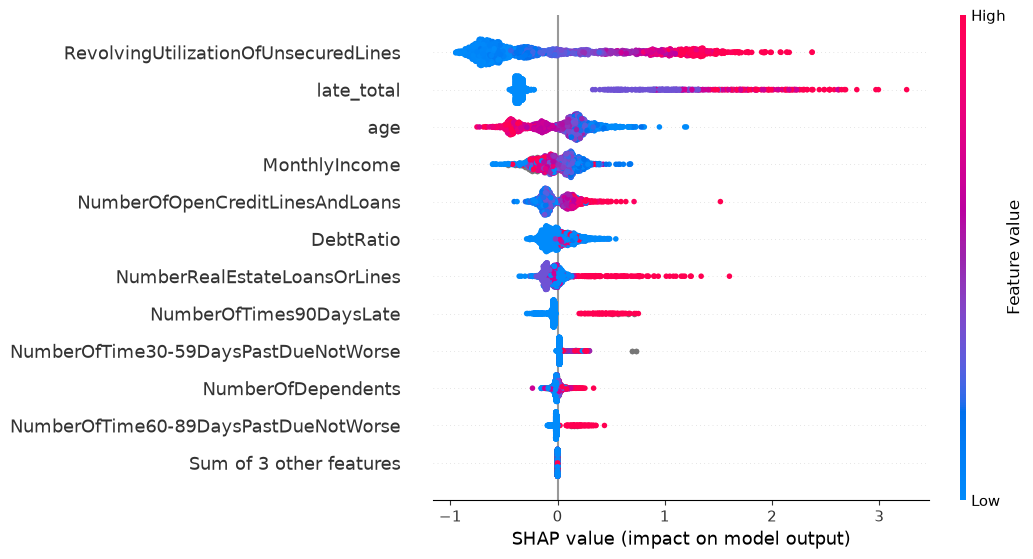

In [26]:
import shap

pre = model.named_steps["features"]   
clf = model.named_steps["model"]  

X_val_tr = pre.transform(X_val)       # признаки в том виде, в каком их видит модель
background = X_val_tr.sample(500, random_state=42)

explainer = shap.TreeExplainer(clf)        
sv = explainer(X_val_tr.iloc[:2000])

shap.plots.beeswarm(sv, max_display=12)


=== максимальный риск: вероятность дефолта 0.799 ===
RevolvingUtilizationOfUnsecuredLines       1.191404
age                                       48.000000
NumberOfTime30-59DaysPastDueNotWorse       2.000000
DebtRatio                                  0.707422
MonthlyIncome                           5119.000000
NumberOfOpenCreditLinesAndLoans            9.000000
NumberOfTimes90DaysLate                    1.000000
NumberRealEstateLoansOrLines               2.000000
NumberOfTime60-89DaysPastDueNotWorse       6.000000
NumberOfDependents                         1.000000
late_code                                  0.000000
income_missing                             0.000000
dependents_missing                         0.000000
late_total                                 9.000000

=== на границе порога: вероятность дефолта 0.164 ===
RevolvingUtilizationOfUnsecuredLines       0.632112
age                                       65.000000
NumberOfTime30-59DaysPastDueNotWorse       3.000000
DebtRati

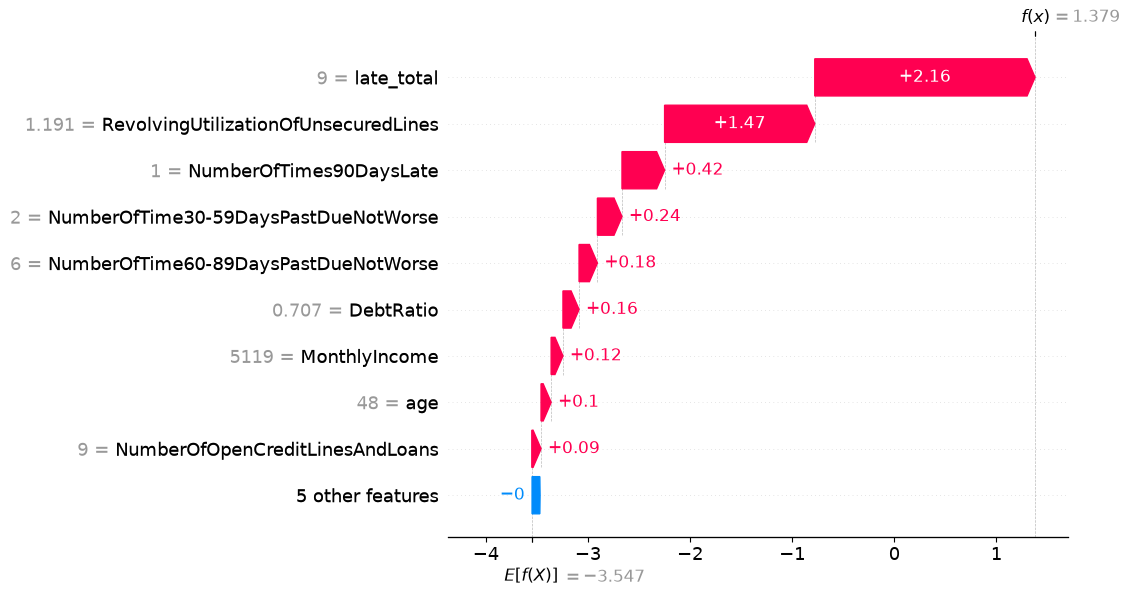

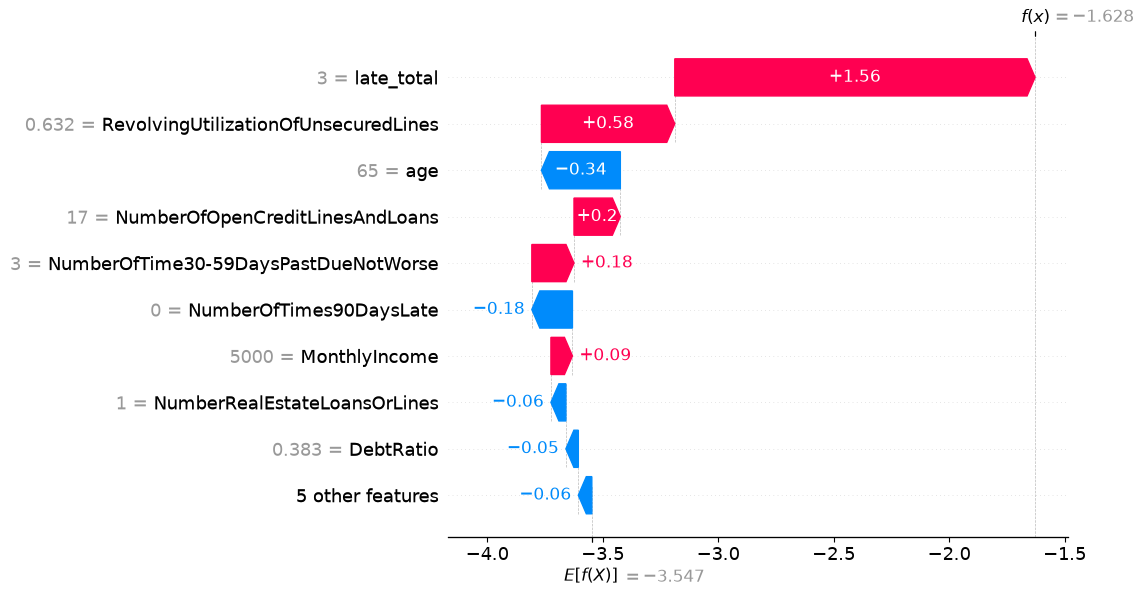

In [29]:
proba_val = clf.predict_proba(X_val_tr.iloc[:2000])[:, 1]

idx_high   = int(np.argmax(proba_val))
idx_border = int(np.abs(proba_val - 0.164).argmin())

for name, i in [("максимальный риск", idx_high), ("на границе порога", idx_border)]:
    print(f"\n=== {name}: вероятность дефолта {proba_val[i]:.3f} ===")
    print(X_val_tr.iloc[i].to_string())

shap.plots.waterfall(sv[idx_high])
shap.plots.waterfall(sv[idx_border])

In [31]:
from sklearn.metrics import roc_auc_score, average_precision_score

final_model = Pipeline([
    ("features", FunctionTransformer(make_features())),
    ("model",    HistGradientBoostingClassifier(random_state=42)),
])
final_model.fit(X_train, y_train)

proba_test = final_model.predict_proba(X_test)[:, 1]
y_test_arr = y_test.values

print("ROC-AUC :", round(roc_auc_score(y_test_arr, proba_test), 4))
print("PR-AUC  :", round(average_precision_score(y_test_arr, proba_test), 4))

approved     = proba_test < 0.164
profit_model = (approved & (y_test_arr == 0)).sum() * 1 + (approved & (y_test_arr == 1)).sum() * (-5)
profit_base  = (y_test_arr == 0).sum() * 1 + (y_test_arr == 1).sum() * (-5)

print("одобрено          :", f"{approved.mean():.1%}")
print("прибыль с моделью :", profit_model)
print("прибыль без модели:", profit_base)
print("прирост           :", f"{profit_model / profit_base - 1:.1%}")

ROC-AUC : 0.8686
PR-AUC  : 0.4065
одобрено          : 89.2%
прибыль с моделью : 21622
прибыль без модели: 17970
прирост           : 20.3%
